In [ ]:
# Cell 1 - Mount Drive and install libraries
from google.colab import drive

try:
    drive.mount('/content/drive')
    print('✅ Drive mounted!')
except:
    print('✅ Drive already mounted!')

!pip install transformers torch scikit-learn -q

print('✅ Libraries installed!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted!
✅ Libraries installed!


In [ ]:
# Cell 2 - Import libraries and check GPU
import pandas as pd
import numpy as np
import torch
import os
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Libraries imported!')
print(f'🖥️ Device: {device}')
if device.type == 'cuda':
    print(f'🖥️ GPU: {torch.cuda.get_device_name(0)}')

✅ Libraries imported!
🖥️ Device: cuda
🖥️ GPU: Tesla T4


In [ ]:
# Cell 3 - Load processed data
base = '/content/drive/MyDrive/PhishingDetector/data/processed'

X_train = pd.read_csv(f'{base}/X_train.csv').squeeze()
X_test = pd.read_csv(f'{base}/X_test.csv').squeeze()
y_train = pd.read_csv(f'{base}/y_train.csv').squeeze()
y_test = pd.read_csv(f'{base}/y_test.csv').squeeze()
extra_train = pd.read_csv(f'{base}/extra_train.csv')
extra_test = pd.read_csv(f'{base}/extra_test.csv')

print(f'✅ Data loaded!')
print(f'📊 Train: {len(X_train)} | Test: {len(X_test)}')
print(f'📊 Train phishing %: {y_train.mean()*100:.1f}%')
print(f'📋 Extra features: {extra_train.columns.tolist()}')

✅ Data loaded!
📊 Train: 63629 | Test: 15908
📊 Train phishing %: 53.3%
📋 Extra features: ['url_count', 'urgency_count', 'email_length', 'word_count']


In [ ]:
# Cell 4 - Create PyTorch Dataset class
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

class EmailDataset(Dataset):
    def __init__(self, texts, labels, max_length=512):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(label, dtype=torch.long)
        }

# Create datasets
train_dataset = EmailDataset(X_train, y_train)
test_dataset = EmailDataset(X_test, y_test)

print(f'✅ Datasets created!')
print(f'📊 Train dataset: {len(train_dataset)} samples')
print(f'📊 Test dataset: {len(test_dataset)} samples')

# Test one sample
sample = train_dataset[0]
print(f'\n🔍 Sample input_ids shape: {sample["input_ids"].shape}')
print(f'🔍 Sample label: {sample["label"]}')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Datasets created!
📊 Train dataset: 63629 samples
📊 Test dataset: 15908 samples

🔍 Sample input_ids shape: torch.Size([512])
🔍 Sample label: 1


In [ ]:
# Cell 5 - Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

print(f'✅ DataLoaders created!')
print(f'📊 Train batches: {len(train_loader)}')
print(f'📊 Test batches: {len(test_loader)}')

✅ DataLoaders created!
📊 Train batches: 3977
📊 Test batches: 995


In [ ]:
# Cell 6 - Load DistilBERT model
from transformers import DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)

model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'✅ Model loaded!')
print(f'📊 Total parameters: {total_params:,}')
print(f'📊 Trainable parameters: {trainable_params:,}')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded!
📊 Total parameters: 66,955,010
📊 Trainable parameters: 66,955,010


In [ ]:
# Cell 7 - Training function
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=2e-5)

def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_idx, batch in enumerate(loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids,
                       attention_mask=attention_mask,
                       labels=labels)

        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        if batch_idx % 200 == 0:
            print(f'   Batch {batch_idx}/{len(loader)} — Loss: {loss.item():.4f}')

    return total_loss / len(loader), correct / total

def evaluate(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids=input_ids,
                           attention_mask=attention_mask)
            preds = outputs.logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds)
    rec = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    return acc, prec, rec, f1

print('✅ Training functions ready!')

✅ Training functions ready!


In [ ]:
# Cell 8 - Train BERT model
import os

EPOCHS = 3
best_f1 = 0
history = {'train_loss': [], 'train_acc': [], 'val_f1': []}

print('🚀 Starting training...')
print(f'📊 Epochs: {EPOCHS}')
print(f'📊 Train batches per epoch: {len(train_loader)}')
print('='*50)

for epoch in range(EPOCHS):
    print(f'\n📌 Epoch {epoch+1}/{EPOCHS}')

    # Train
    train_loss, train_acc = train_epoch(model, train_loader, optimizer)

    # Evaluate
    val_acc, val_prec, val_rec, val_f1 = evaluate(model, test_loader)

    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_f1'].append(val_f1)

    print(f'\n✅ Epoch {epoch+1} Results:')
    print(f'   Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%')
    print(f'   Val Acc: {val_acc*100:.2f}% | Precision: {val_prec*100:.2f}%')
    print(f'   Recall: {val_rec*100:.2f}% | F1: {val_f1*100:.2f}%')

    # Save best model
    if val_f1 > best_f1:
        best_f1 = val_f1
        os.makedirs('/content/drive/MyDrive/PhishingDetector/models', exist_ok=True)
        model.save_pretrained('/content/drive/MyDrive/PhishingDetector/models/bert_model')
        print(f'   💾 Best model saved! F1: {best_f1*100:.2f}%')

print('\n🎉 Training complete!')
print(f'🏆 Best F1 Score: {best_f1*100:.2f}%')

🚀 Starting training...
📊 Epochs: 3
📊 Train batches per epoch: 3977

📌 Epoch 1/3
   Batch 0/3977 — Loss: 0.7349
   Batch 200/3977 — Loss: 0.0784
   Batch 400/3977 — Loss: 0.0324
   Batch 600/3977 — Loss: 0.0081
   Batch 800/3977 — Loss: 0.0145
   Batch 1000/3977 — Loss: 0.0145
   Batch 1200/3977 — Loss: 0.0255
   Batch 1400/3977 — Loss: 0.1449
   Batch 1600/3977 — Loss: 0.0029
   Batch 1800/3977 — Loss: 0.0076
   Batch 2000/3977 — Loss: 0.0305
   Batch 2200/3977 — Loss: 0.0135
   Batch 2400/3977 — Loss: 0.0026
   Batch 2600/3977 — Loss: 0.1148
   Batch 2800/3977 — Loss: 0.0012
   Batch 3000/3977 — Loss: 0.0129
   Batch 3200/3977 — Loss: 0.0010
   Batch 3400/3977 — Loss: 0.0289
   Batch 3600/3977 — Loss: 0.1602
   Batch 3800/3977 — Loss: 0.0046

✅ Epoch 1 Results:
   Train Loss: 0.0622 | Train Acc: 97.71%
   Val Acc: 99.00% | Precision: 99.28%
   Recall: 98.84% | F1: 99.06%


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   💾 Best model saved! F1: 99.06%

📌 Epoch 2/3
   Batch 0/3977 — Loss: 0.0018
   Batch 200/3977 — Loss: 0.0058
   Batch 400/3977 — Loss: 0.0004
   Batch 600/3977 — Loss: 0.1751
   Batch 800/3977 — Loss: 0.0002
   Batch 1000/3977 — Loss: 0.0017
   Batch 1200/3977 — Loss: 0.0040
   Batch 1400/3977 — Loss: 0.0004
   Batch 1600/3977 — Loss: 0.0009
   Batch 1800/3977 — Loss: 0.0031
   Batch 2000/3977 — Loss: 0.0144
   Batch 2200/3977 — Loss: 0.0010
   Batch 2400/3977 — Loss: 0.0003
   Batch 2600/3977 — Loss: 0.0009
   Batch 2800/3977 — Loss: 0.0003
   Batch 3000/3977 — Loss: 0.0004
   Batch 3200/3977 — Loss: 0.0013
   Batch 3400/3977 — Loss: 0.0002
   Batch 3600/3977 — Loss: 0.0002
   Batch 3800/3977 — Loss: 0.0011

✅ Epoch 2 Results:
   Train Loss: 0.0164 | Train Acc: 99.48%
   Val Acc: 99.20% | Precision: 99.05%
   Recall: 99.46% | F1: 99.25%


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   💾 Best model saved! F1: 99.25%

📌 Epoch 3/3
   Batch 0/3977 — Loss: 0.0004
   Batch 200/3977 — Loss: 0.0003
   Batch 400/3977 — Loss: 0.0004
   Batch 600/3977 — Loss: 0.0001
   Batch 800/3977 — Loss: 0.0001
   Batch 1000/3977 — Loss: 0.0001
   Batch 1200/3977 — Loss: 0.0002
   Batch 1400/3977 — Loss: 0.0251
   Batch 1600/3977 — Loss: 0.0191
   Batch 1800/3977 — Loss: 0.0003
   Batch 2000/3977 — Loss: 0.0001
   Batch 2200/3977 — Loss: 0.1383
   Batch 2400/3977 — Loss: 0.0004
   Batch 2600/3977 — Loss: 0.0001
   Batch 2800/3977 — Loss: 0.0061
   Batch 3000/3977 — Loss: 0.0004
   Batch 3200/3977 — Loss: 0.0004
   Batch 3400/3977 — Loss: 0.0001
   Batch 3600/3977 — Loss: 0.0001
   Batch 3800/3977 — Loss: 0.0022

✅ Epoch 3 Results:
   Train Loss: 0.0073 | Train Acc: 99.79%
   Val Acc: 99.16% | Precision: 99.52%
   Recall: 98.90% | F1: 99.21%

🎉 Training complete!
🏆 Best F1 Score: 99.25%


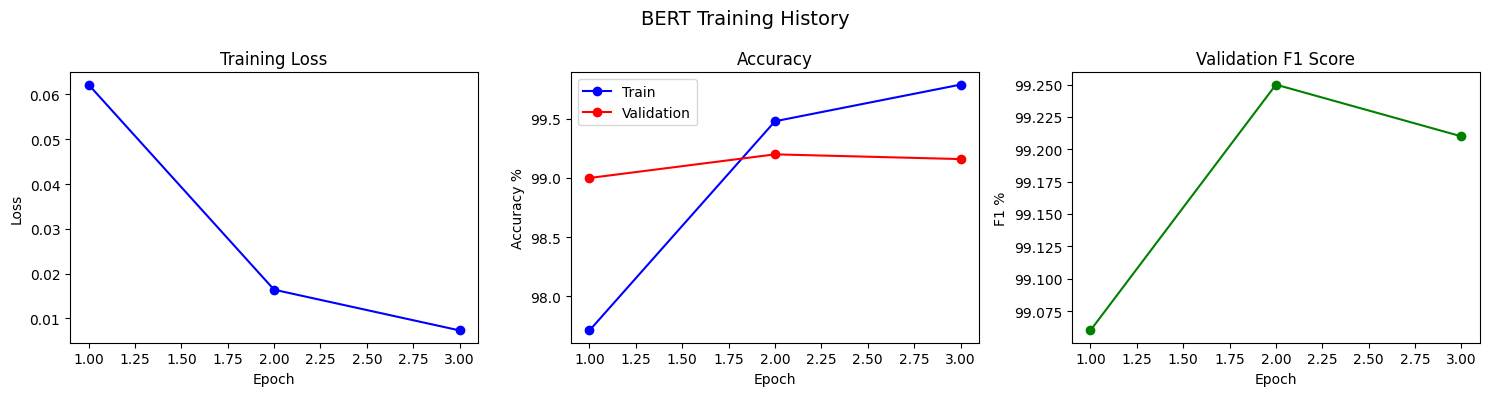

✅ Plot saved!


In [ ]:
# Cell 9 - Plot training history
import matplotlib.pyplot as plt
import os

os.makedirs('/content/drive/MyDrive/PhishingDetector/plots', exist_ok=True)

epochs = [1, 2, 3]
train_loss = [0.0622, 0.0164, 0.0073]
train_acc = [97.71, 99.48, 99.79]
val_acc = [99.00, 99.20, 99.16]
val_f1 = [99.06, 99.25, 99.21]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1 - Loss
axes[0].plot(epochs, train_loss, 'b-o')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

# Plot 2 - Accuracy
axes[1].plot(epochs, train_acc, 'b-o', label='Train')
axes[1].plot(epochs, val_acc, 'r-o', label='Validation')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy %')
axes[1].legend()

# Plot 3 - F1
axes[2].plot(epochs, val_f1, 'g-o')
axes[2].set_title('Validation F1 Score')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 %')

plt.suptitle('BERT Training History', fontsize=14)
plt.tight_layout()

save_path = '/content/drive/MyDrive/PhishingDetector/plots/training_history.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved!')

🖥️ Device: cuda


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

✅ Model reloaded!


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Test data ready! Samples: 15908

📊 Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99      7436
    Phishing       0.99      0.99      0.99      8472

    accuracy                           0.99     15908
   macro avg       0.99      0.99      0.99     15908
weighted avg       0.99      0.99      0.99     15908



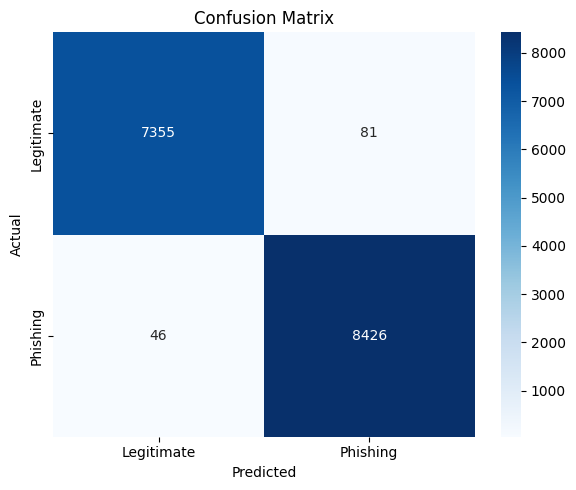

✅ Confusion matrix saved!


In [ ]:
# Cell 10 - Reload model and evaluate
import torch
import pandas as pd
from transformers import DistilBertForSequenceClassification, DistilBertTokenizer
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️ Device: {device}')

# Reload model
model = DistilBertForSequenceClassification.from_pretrained(
    '/content/drive/MyDrive/PhishingDetector/models/bert_model'
)
model = model.to(device)
model.eval()
print('✅ Model reloaded!')

# Reload tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Reload test data
base = '/content/drive/MyDrive/PhishingDetector/data/processed'
X_test = pd.read_csv(f'{base}/X_test.csv').squeeze()
y_test = pd.read_csv(f'{base}/y_test.csv').squeeze()

# Recreate dataset
class EmailDataset(Dataset):
    def __init__(self, texts, labels, max_length=512):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.max_length = max_length
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        encoding = tokenizer(
            str(self.texts[idx]),
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(int(self.labels[idx]), dtype=torch.long)
        }

test_dataset = EmailDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
print(f'✅ Test data ready! Samples: {len(test_dataset)}')

# Get predictions
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = outputs.logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Classification report
print('\n📊 Classification Report:')
print(classification_report(all_labels, all_preds,
      target_names=['Legitimate', 'Phishing']))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()

save_path = '/content/drive/MyDrive/PhishingDetector/plots/confusion_matrix.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrix saved!')